In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0,Xception,ConvNeXtTiny,VGG19, DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import cv2
import imutils
from tensorflow.keras.optimizers import Adam

2025-06-17 18:42:31.375542: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750185751.586588      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750185751.653273      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# laod Kagle dateset
train_dir = "/kaggle/input/research-dataset/Kaggle/Training"

# Read all images and their labels
all_images = []
for class_name in os.listdir(train_dir):
    class_dir = os.path.join(train_dir, class_name)
    if not os.path.isdir(class_dir):
        continue
    for img_file in os.listdir(class_dir):
        all_images.append({
            "image_path": os.path.join(class_dir, img_file),
            "label": class_name
        })

kaggle_df = pd.DataFrame(all_images)

# Encode labels
label_to_idx = {label: idx for idx, label in enumerate(sorted(kaggle_df["label"].unique()))}
kaggle_df["label"] = kaggle_df["label"].map(label_to_idx)

# Stratified split (80% train, 20% val)
train_df, val_df = train_test_split(kaggle_df, test_size=0.2, stratify=kaggle_df["label"], random_state=42)

print(f"Kaggle split: Train = {len(train_df)}, Val = {len(val_df)}")

Kaggle split: Train = 4569, Val = 1143


In [3]:
# Load OASIS 
oasis_root = "/kaggle/input/research-dataset/OASIS"

labels_df = pd.read_csv(os.path.join(oasis_root, "labels.csv"))

# Check for dementia_multi column
if 'dementia_multi' not in labels_df.columns:
    raise ValueError("Column 'dementia_multi' not found in the CSV file. Available columns: " + str(labels_df.columns.tolist()))

# Create image paths
labels_df["image_path"] = labels_df["ID"].apply(
    lambda x: os.path.join("/kaggle/input/research-dataset/OASIS", f"{x}_slice0.png")
)

# Rename the label column
labels_df = labels_df.rename(columns={"dementia_multi": "label"})

# Handle label conversion
if labels_df["label"].dtype == object:
    label_mapping = {
        "Control": 0,
        "MildCognitiveImpairment": 1,
        "Demented": 2
    }
    labels_df["label"] = labels_df["label"].map(label_mapping)
    
    # Verify mapping
    if labels_df["label"].isna().any():
        unmapped = labels_df[labels_df["label"].isna()]["label"].unique()
        raise ValueError(f"Some labels were not mapped: {unmapped}")


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 25
BASE_MODEL_NAME =  "DenseNet121" # or any other

In [5]:
def crop_img(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    thresh = cv2.threshold(blurred, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    if not cnts:
        return None

    c = max(cnts, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    return img[y:y+h, x:x+w]

def process_folder(input_root, output_root):
    for category in os.listdir(input_root):
        category_path = os.path.join(input_root, category)
        if not os.path.isdir(category_path):
            continue

        save_dir = os.path.join(output_root, category)
        os.makedirs(save_dir, exist_ok=True)

        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            cropped = crop_img(img)
            if cropped is None:
                continue

            resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
            save_path = os.path.join(save_dir, img_name)
            cv2.imwrite(save_path, resized)

if __name__ == "__main__":
    process_folder("/kaggle/input/research-dataset/Kaggle/Training", "cleaned/Training")
    process_folder("/kaggle/input/research-dataset/Kaggle/Testing", "cleaned/Testing")

In [6]:
# === DATA LOADERS ===
train_dir = "cleaned/Training"
val_dir = "cleaned/Testing"

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(train_dir,
                                           target_size=(IMG_SIZE, IMG_SIZE),
                                           batch_size=BATCH_SIZE,
                                           class_mode='categorical')

val_data = val_gen.flow_from_directory(val_dir,
                                       target_size=(IMG_SIZE, IMG_SIZE),
                                       batch_size=BATCH_SIZE,
                                       class_mode='categorical',
                                       shuffle=False)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [7]:
def get_model(base="EfficientNetB0", trainable_layers=0, input_shape=(224, 224, 3), num_classes=4):
    # Load base model
    if base == "ResNet50":
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base == "EfficientNetB0":
        base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base == "Xception":
      base_model = Xception(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base == "ConvNeXtTiny":
      base_model = ConvNeXtTiny(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base == "DenseNet121":
        base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base == "VGG19":
        base_model = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError("Unsupported model")

    # Freeze all layers first
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze last `trainable_layers` layers if specified
    if trainable_layers > 0:
        for layer in base_model.layers[-trainable_layers:]:
            layer.trainable = True

    # # Add custom top
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    # model = Model(inputs=base_model.input, outputs=outputs)

    # x = base_model.output
    # x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # x = tf.keras.layers.Dense(512, activation='swish')(x)  # New!
    # x = tf.keras.layers.Dropout(0.3)(x)  # Adjusted from 0.2
    # outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model


In [8]:
model = get_model(base=BASE_MODEL_NAME, trainable_layers=10, num_classes=NUM_CLASSES)
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_data, validation_data=val_data, epochs=25)

I0000 00:00:1750185829.036483      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750185829.037176      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1750185852.695166     111 service.cc:148] XLA service 0x7dedec003580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750185852.696046     111 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1750185852.696075     111 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1750185855.490370     111 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/179 ━━━━━━━━━━━━━━━━━━━━ 1:43:35 35s/step - accuracy: 0.1875 - loss: 1.9634

I0000 00:00:1750185867.726934     111 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


179/179 ━━━━━━━━━━━━━━━━━━━━ 86s 286ms/step - accuracy: 0.5305 - loss: 1.1444 - val_accuracy: 0.7841 - val_loss: 0.5960
Epoch 2/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - accuracy: 0.8566 - loss: 0.4954 - val_accuracy: 0.8520 - val_loss: 0.4338
Epoch 3/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.9130 - loss: 0.3385 - val_accuracy: 0.8917 - val_loss: 0.3376
Epoch 4/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - accuracy: 0.9233 - loss: 0.2759 - val_accuracy: 0.9115 - val_loss: 0.2735
Epoch 5/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 18s 101ms/step - accuracy: 0.9488 - loss: 0.2166 - val_accuracy: 0.9352 - val_loss: 0.2268
Epoch 6/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - accuracy: 0.9689 - loss: 0.1568 - val_accuracy: 0.9466 - val_loss: 0.1816
Epoch 7/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - accuracy: 0.9752 - loss: 0.1234 - val_accuracy: 0.9596 - val_loss: 0.1535
Epoch 8/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - accuracy: 0.9838 - loss: 0.0994 - val_ac

In [9]:
model.evaluate(val_data)

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.9711 - loss: 0.0710


[0.04818907380104065, 0.9824561476707458]

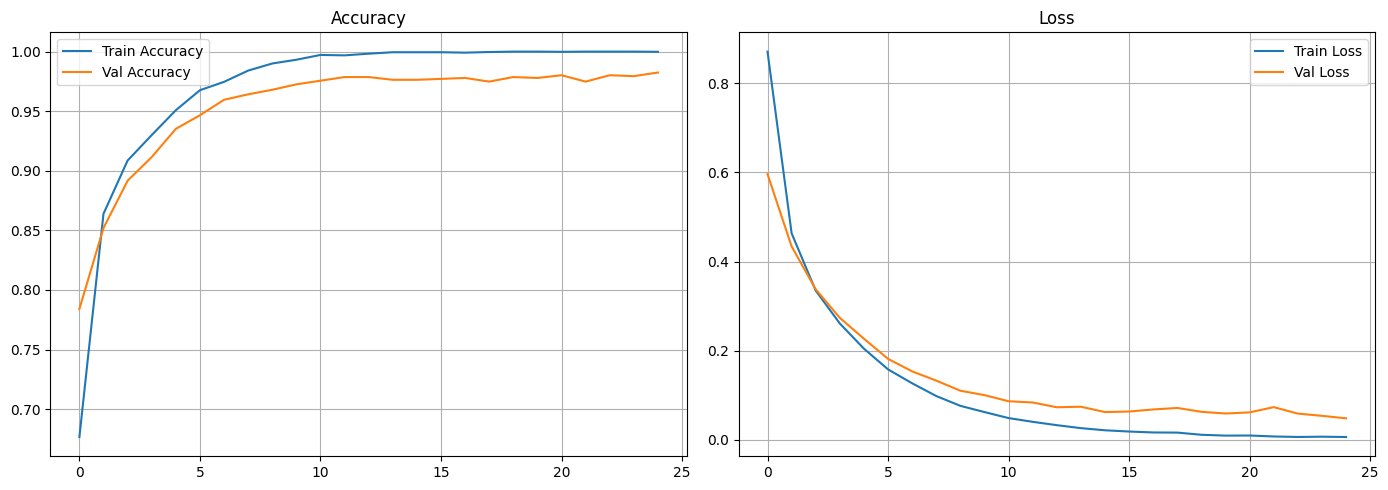

In [10]:
def plot_metrics(history):
    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title("Accuracy")
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_metrics(history)


41/41 ━━━━━━━━━━━━━━━━━━━━ 25s 357ms/step
=== Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       300
           1       0.96      0.98      0.97       306
           2       1.00      1.00      1.00       405
           3       0.98      0.99      0.99       300

    accuracy                           0.98      1311
   macro avg       0.98      0.98      0.98      1311
weighted avg       0.98      0.98      0.98      1311

=== Confusion Matrix ===


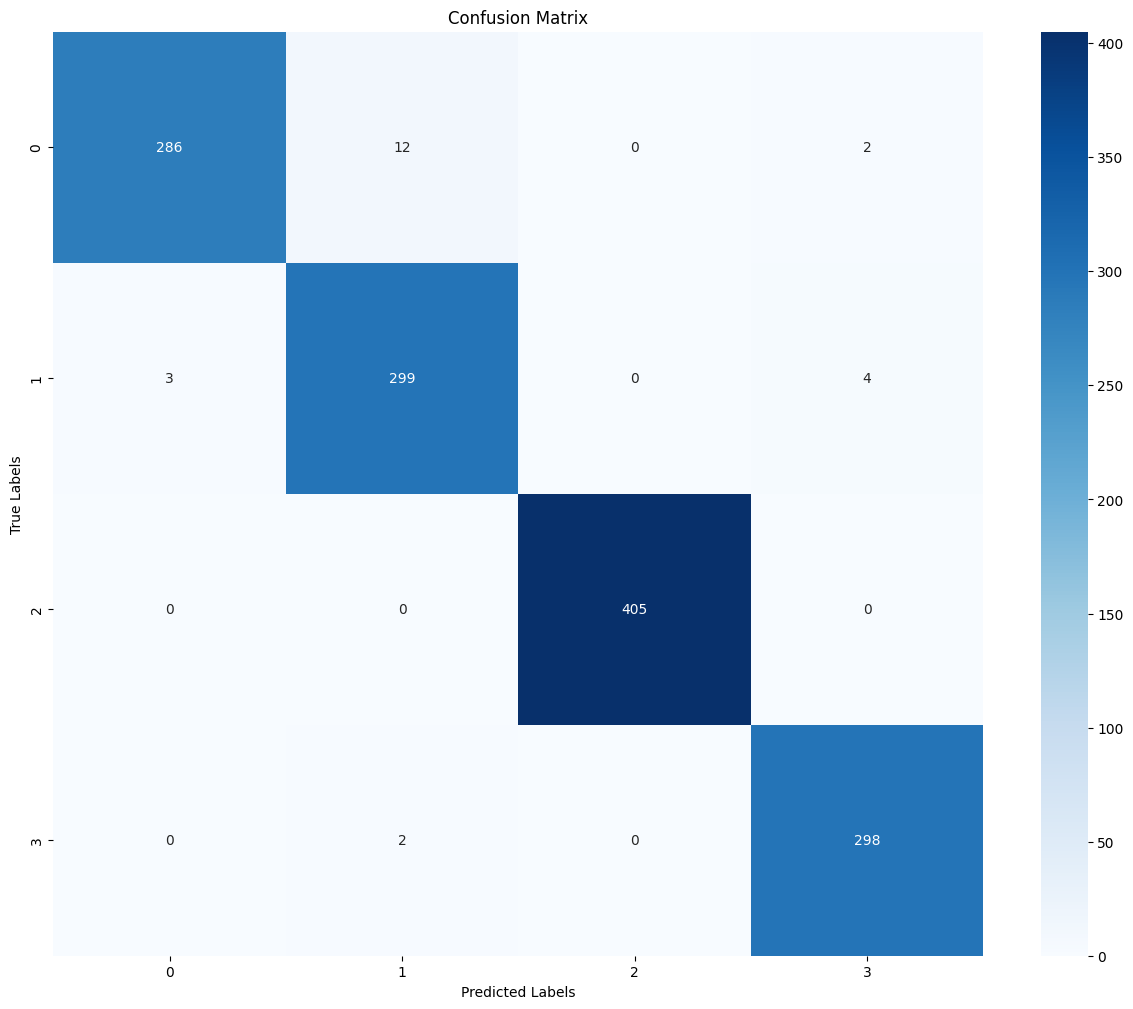

In [11]:
# Predictions
preds = model.predict(val_data)
y_pred = np.argmax(preds, axis=1)
y_true = val_data.classes

# Classification report
print("=== Classification Report ===")
print(classification_report(y_true, y_pred))

# Confusion matrix
print("=== Confusion Matrix ===")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # annot=True and fmt='d' for integer formatting
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


In [12]:
def adapt_model_for_oasis(original_model, num_classes=3, trainable_head_layers=1):
    # 1. Get the layer before the original classification head
    if isinstance(original_model.layers[-2], GlobalAveragePooling2D):
        feature_extractor_output = original_model.layers[-2].output
    else:
        # Handle cases where the architecture might be different
        feature_extractor_output = original_model.layers[-3].output  # assuming -2 is Dropout
    
    # 2. Create a more robust new head
    x = feature_extractor_output
    x = Dense(512, activation='swish')(x)  # Added dense layer
    x = Dropout(0.5)(x)  # More aggressive dropout for regularization
    new_head = Dense(num_classes, activation='softmax')(x)
    
    # 3. Create new model
    oasis_model = Model(inputs=original_model.input, outputs=new_head)
    
    # 4. Freeze all layers except potentially last N of base model
    for layer in oasis_model.layers[:-3]:  # Freeze everything except new head layers
        layer.trainable = False
    
    # 5. Compile
    oasis_model.compile(
        optimizer=Adam(learning_rate=1e-3),  # Higher LR for head training
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return oasis_model

# Usage:
oasis_model = adapt_model_for_oasis(model, num_classes=3)

In [13]:
# === 1. LOAD LABELS ===
labels_df = pd.read_csv("/kaggle/input/research-dataset/OASIS/labels.csv")

# First check if 'dimentia_multi' column exists
if 'dementia_multi' not in labels_df.columns:
    raise ValueError("Column 'dimentia_multi' not found in the CSV file. Available columns: " + str(labels_df.columns.tolist()))

# Create image paths
labels_df["image_path"] = labels_df["ID"].apply(
    lambda x: os.path.join("/kaggle/input/research-dataset/OASIS", f"{x}_slice0.png")
)

# Rename the label column
labels_df = labels_df.rename(columns={"dementia_multi": "label"})

# Now handle label conversion if needed
if labels_df["label"].dtype == object:
    # Adjust this mapping to match your actual class names
    label_mapping = {
        "Control": 0,
        "MildCognitiveImpairment": 1,  # Note: Fix typo if needed
        "Demented": 2
    }
    labels_df["label"] = labels_df["label"].map(label_mapping)
    
    # Verify all labels were mapped
    if labels_df["label"].isna().any():
        unmapped = labels_df[labels_df["label"].isna()]["label"].unique()
        raise ValueError(f"Some labels were not mapped: {unmapped}")

In [14]:
def process_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)  # ← switch from decode_image
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def make_dataset(df, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((df["image_path"].values, df["label"].values))
    ds = ds.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    if augment:
        ds = ds.map(lambda x, y: (augment_image(x), y), 
                   num_parallel_calls=tf.data.AUTOTUNE)
    
    ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

def augment_image(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.image.random_hue(image, max_delta=0.1)
    # Random zoom and crop
    image = tf.image.central_crop(image, central_fraction=0.8)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image


In [15]:
train_df, val_df = train_test_split(labels_df, test_size=0.2, stratify=labels_df["label"], random_state=42)

In [16]:
# Training dataset with augmentation
train_ds = make_dataset(train_df, augment=True)

# Validation dataset without augmentation
val_ds = make_dataset(val_df, augment=False)

In [17]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(train_df["label"]), y=train_df["label"])
class_weight_dict = dict(enumerate(class_weights))

In [18]:

oasis_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Add callbacks
# callbacks = [
#     EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5)
# ]

# Train just the head
history = oasis_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    # callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 65s 4s/step - accuracy: 0.3996 - loss: 1.7872 - val_accuracy: 0.6364 - val_loss: 0.8453
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.3940 - loss: 1.7510 - val_accuracy: 0.2045 - val_loss: 1.3057
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.4302 - loss: 2.0082 - val_accuracy: 0.1818 - val_loss: 1.5253
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.3748 - loss: 1.3415 - val_accuracy: 0.1477 - val_loss: 1.8241
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.5592 - loss: 0.9080 - val_accuracy: 0.2841 - val_loss: 1.2861
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.4936 - loss: 1.0194 - val_accuracy: 0.3409 - val_loss: 1.2141
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.6082 - loss: 0.9086 - val_accuracy: 0.4659 - val_loss: 1.2372
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.5443 - loss: 1.0181 - val_accuracy: 0.53


=== Making Predictions ===

=== Classification Report ===
              precision    recall  f1-score   support

     Control     1.0000    0.2353    0.3810        68
         MCI     0.1944    1.0000    0.3256        14
    Demented     0.0000    0.0000    0.0000         6

    accuracy                         0.3409        88
   macro avg     0.3981    0.4118    0.2355        88
weighted avg     0.8037    0.3409    0.3462        88


=== Confusion Matrix ===


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


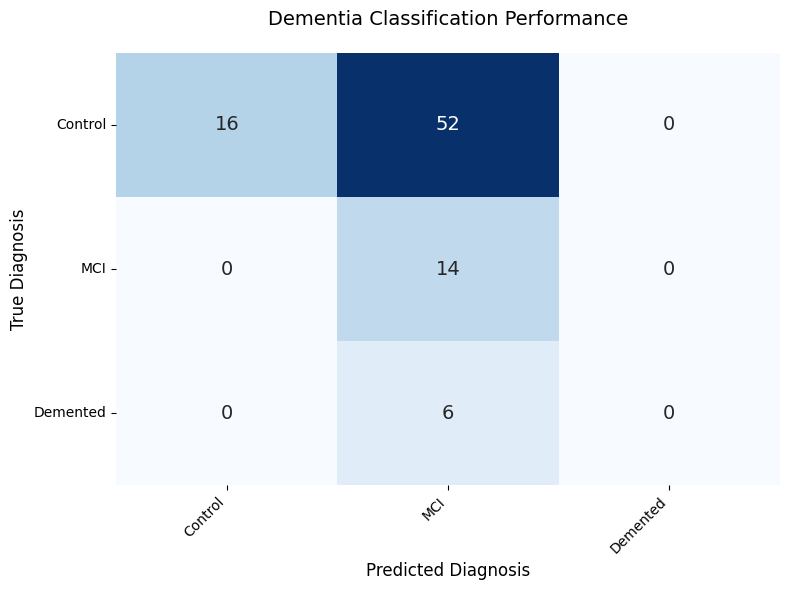

In [19]:
# === EVALUATION CELL (Matches Your Training Setup) ===

# Define class names matching your label mapping
class_names = ['Control', 'MCI', 'Demented']  # MCI = MildCognitiveImpairment

# Get predictions and true labels
print("\n=== Making Predictions ===")
y_pred = []
y_true = []

for images, labels in val_ds:
    preds = oasis_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, 
                           target_names=class_names,
                           digits=4))

# Confusion matrix with clinical formatting
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=False,
            annot_kws={"size": 14})
plt.title("Dementia Classification Performance", fontsize=14, pad=20)
plt.xlabel("Predicted Diagnosis", fontsize=12)
plt.ylabel("True Diagnosis", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# # Clinical performance metrics
# print("\n=== Clinical Metrics ===")
# print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}")
# print(f"AD Detection Sensitivity: {recall_score(y_true, y_pred, pos_label=2):.4f}")
# print(f"AD Detection Specificity: {1 - (cm[0,2] + cm[1,2]) / (cm[0,:].sum() + cm[1,:].sum()):.4f}")
# print(f"MCI Detection F1-Score: {f1_score(y_true, y_pred, pos_label=1):.4f}")